# Polities — assigning individuals to historical polities and mapping their activity per century.

## Setup

In [1]:
import json
import random
from collections import defaultdict
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import FancyArrowPatch, Polygon
from shapely.geometry import shape
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH      = '../../data/humans_clean.duckdb'
BASEMAP_PATH = '../../data/ne_110m_admin_0_countries.geojson'

COLORS = {
    'polygon_deathplace':  '#1f4f7a',
    'polygon_birthplace':  '#3a8fbf',
    'polygon_nationality': '#7fb8d6',
    'url_nationality':     '#b5542a',
    'url_deathplace':      '#d97a4f',
    'url_birthplace':      '#e8a37a',
    'navy':                '#1f3a5f',
    'teal':                '#0f766e',
    'orange':              '#d97706',
    'grey':                '#6b7280',
    'light_grey':          '#f3f4f6',
    'light_blue':          '#dbe4ee',
    'light_teal':          '#cce7e2',
}

CENTURY_SNAPSHOTS = [-400, 500, 1400, 1900]
MAP_COLORMAP      = 'magma'

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   11,
})

/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Schematic — how a location is assigned to a polity

Polygon test (parity rule: odd number of edge crossings → inside) followed by smallest-bounding-box tie-break when several polygons enclose the point.

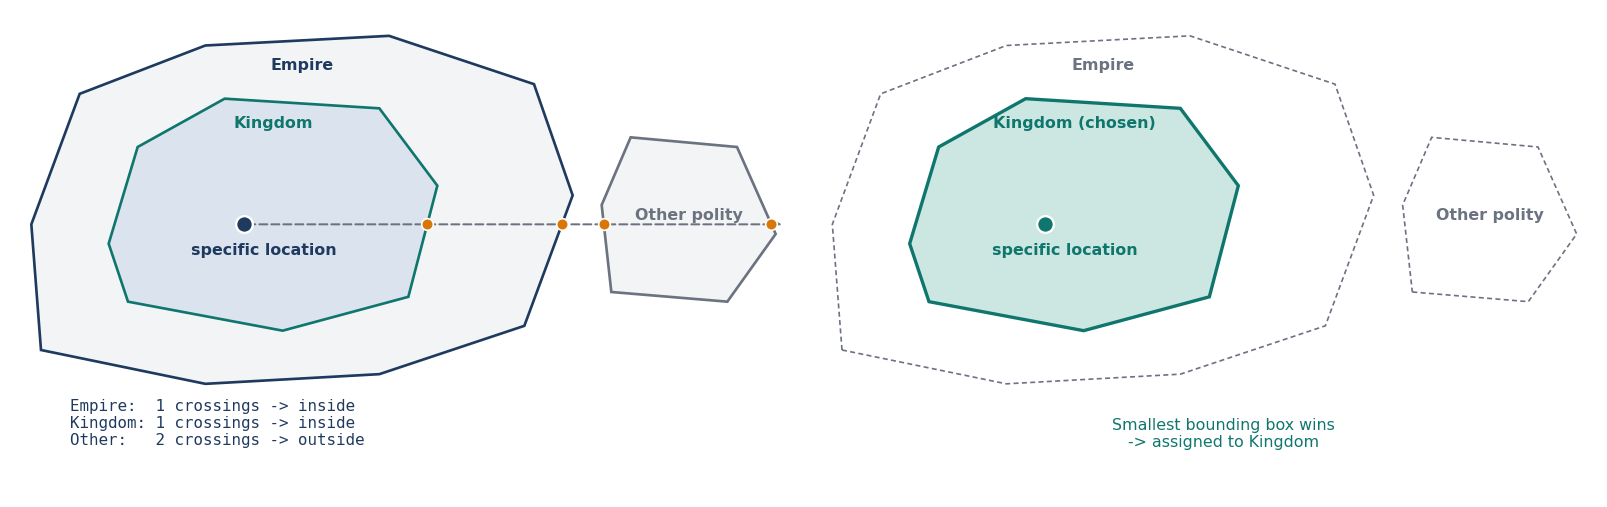

In [2]:
EMPIRE_POLYGON = [
    (-0.4, 0.4), (3.0, -0.3), (6.6, -0.1), (9.6, 0.9),
    (10.6, 3.6), (9.8, 5.9), (6.8, 6.9), (3.0, 6.7),
    (0.4, 5.7), (-0.6, 3.0),
]
KINGDOM_POLYGON = [
    (1.4, 1.4), (4.6, 0.8), (7.2, 1.5), (7.8, 3.8),
    (6.6, 5.4), (3.4, 5.6), (1.6, 4.6), (1.0, 2.6),
]
OTHER_POLYGON = [
    (11.4, 1.6), (13.8, 1.4), (14.8, 2.8), (14.0, 4.6),
    (11.8, 4.8), (11.2, 3.4),
]
TEST_POINT = (3.8, 3.0)
RAY_X_MAX  = 15.2

def edge_crossings(point, polygon, x_max):
    px, py = point
    crossings = []
    n = len(polygon)
    for i in range(n):
        x1, y1 = polygon[i]
        x2, y2 = polygon[(i + 1) % n]
        if (y1 > py) == (y2 > py):
            continue
        x_intersect = x1 + (py - y1) * (x2 - x1) / (y2 - y1)
        if px < x_intersect <= x_max:
            crossings.append((x_intersect, py))
    return sorted(crossings)

def draw_polygon(ax, coords, face, edge, label, label_xy, label_color, lw=1.6, ls='-'):
    ax.add_patch(Polygon(coords, closed=True, facecolor=face, edgecolor=edge, linewidth=lw, linestyle=ls))
    ax.text(*label_xy, label, fontsize=9.5, color=label_color, fontweight='bold', ha='center')

def draw_ray(ax, start, end):
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle='->', mutation_scale=12,
        color=COLORS['grey'], linewidth=1.2, linestyle=(0, (4, 2)),
    ))

def draw_point(ax, point, color, label):
    ax.plot(*point, 'o', color=color, markersize=10, markeredgecolor='white', markeredgewidth=1.4, zorder=5)
    ax.annotate(label, point, xytext=(-32, -18), textcoords='offset points',
                fontsize=9.5, color=color, fontweight='bold')

def draw_crossings(ax, crossings):
    for cx, cy in crossings:
        ax.plot(cx, cy, 'o', color=COLORS['orange'], markersize=7,
                markeredgecolor='white', markeredgewidth=1.0, zorder=4)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

ax = axes[0]
draw_polygon(ax, EMPIRE_POLYGON,  COLORS['light_grey'], COLORS['navy'], 'Empire',       (5.0, 6.2),  COLORS['navy'])
draw_polygon(ax, KINGDOM_POLYGON, COLORS['light_blue'], COLORS['teal'], 'Kingdom',      (4.4, 5.0),  COLORS['teal'])
draw_polygon(ax, OTHER_POLYGON,   COLORS['light_grey'], COLORS['grey'], 'Other polity', (13.0, 3.1), COLORS['grey'])
draw_ray(ax, TEST_POINT, (RAY_X_MAX - 0.2, TEST_POINT[1]))
empire_x  = edge_crossings(TEST_POINT, EMPIRE_POLYGON,  RAY_X_MAX)
kingdom_x = edge_crossings(TEST_POINT, KINGDOM_POLYGON, RAY_X_MAX)
other_x   = edge_crossings(TEST_POINT, OTHER_POLYGON,   RAY_X_MAX)
draw_crossings(ax, empire_x + kingdom_x + other_x)
draw_point(ax, TEST_POINT, COLORS['navy'], 'specific location')
ax.text(0.2, -0.6,
        f'Empire:  {len(empire_x)} crossings -> inside\n'
        f'Kingdom: {len(kingdom_x)} crossings -> inside\n'
        f'Other:   {len(other_x)} crossings -> outside',
        fontsize=9.5, color=COLORS['navy'], family='monospace', verticalalignment='top')
ax.set_xlim(-1.0, RAY_X_MAX); ax.set_ylim(-2.6, 7.4); ax.set_aspect('equal'); ax.axis('off')

ax = axes[1]
draw_polygon(ax, EMPIRE_POLYGON,  'white', COLORS['grey'], 'Empire',       (5.0, 6.2),  COLORS['grey'], lw=1.0, ls=(0, (3, 2)))
draw_polygon(ax, KINGDOM_POLYGON, COLORS['light_teal'], COLORS['teal'], 'Kingdom (chosen)', (4.4, 5.0),  COLORS['teal'], lw=2.0)
draw_polygon(ax, OTHER_POLYGON,   'white', COLORS['grey'], 'Other polity', (13.0, 3.1), COLORS['grey'], lw=1.0, ls=(0, (3, 2)))
draw_point(ax, TEST_POINT, COLORS['teal'], 'specific location')
ax.text(7.5, -1.6, 'Smallest bounding box wins\n-> assigned to Kingdom',
        fontsize=9.5, color=COLORS['teal'], ha='center')
ax.set_xlim(-1.0, RAY_X_MAX); ax.set_ylim(-2.6, 7.4); ax.set_aspect('equal'); ax.axis('off')

fig.tight_layout()
plt.show()

## Connect

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)

## Match cascade — one row per matched individual (method, origin)

In [4]:
matches_raw = con.execute("""
    SELECT wikidata_id, method, origin
    FROM   individuals_cliopatria
""").pl()

print('shape:', matches_raw.shape)
matches_raw.head()

shape: (5065026, 3)


wikidata_id,method,origin
str,str,str
"""Q107522""","""merge_with_polygon""","""deathplace"""
"""Q107522041""","""merge_with_polygon""","""deathplace"""
"""Q107522056""","""merge_with_polygon""","""birthplace"""
"""Q107522108""","""merge_with_polygon""","""birthplace"""
"""Q107522122""","""merge_with_polygon""","""birthplace"""


In [5]:
method_label = {
    'merge_with_polygon': 'polygon',
    'merge_with_url':     'url',
}
origin_label = {
    'country_of_citizenship': 'nationality',
    'birthplace':             'birthplace',
    'deathplace':             'deathplace',
}

matches = matches_raw.with_columns(
    pl.col('method').replace(method_label).alias('method'),
    pl.col('origin').replace(origin_label).alias('origin'),
)

print('shape:', matches.shape)
matches.head()

shape: (5065026, 3)


wikidata_id,method,origin
str,str,str
"""Q107522""","""polygon""","""deathplace"""
"""Q107522041""","""polygon""","""deathplace"""
"""Q107522056""","""polygon""","""birthplace"""
"""Q107522108""","""polygon""","""birthplace"""
"""Q107522122""","""polygon""","""birthplace"""


## Denominators — total, dated, dated AND located

In [6]:
n_individuals = con.execute(
    'SELECT COUNT(*) FROM individuals'
).fetchone()[0]

n_dated = con.execute('''
    SELECT COUNT(*)
    FROM   individuals_floruit_period
    WHERE  floruit_year IS NOT NULL
       OR (floruit_period_start IS NOT NULL AND floruit_period_end IS NOT NULL)
''').fetchone()[0]

n_dated_and_located = con.execute('''
    SELECT COUNT(DISTINCT floruit.wikidata_id)
    FROM        individuals_floruit_period AS floruit
    INNER JOIN  individuals_keys           AS keys USING (wikidata_id)
    WHERE       (floruit.floruit_year IS NOT NULL
                 OR (floruit.floruit_period_start IS NOT NULL
                     AND floruit.floruit_period_end IS NOT NULL))
      AND       (keys.birthcity_id               IS NOT NULL
                 OR keys.deathcity_id            IS NOT NULL
                 OR keys.country_of_citizenship_ids IS NOT NULL)
''').fetchone()[0]

n_matched = con.execute(
    'SELECT COUNT(DISTINCT wikidata_id) FROM individuals_cliopatria'
).fetchone()[0]

print(f'individuals (total)            : {n_individuals:,}')
print(f'dated individuals              : {n_dated:,}')
print(f'dated AND located individuals  : {n_dated_and_located:,}')
print(f'matched (assigned to a polity) : {n_matched:,}')

individuals (total)            : 13,003,420
dated individuals              : 9,683,814
dated AND located individuals  : 5,199,978
matched (assigned to a polity) : 5,065,026


## Linkage breakdown — counts in cascade order

In [7]:
CASCADE_ORDER = [
    ('polygon', 'deathplace'),
    ('polygon', 'birthplace'),
    ('polygon', 'nationality'),
    ('url',     'nationality'),
    ('url',     'deathplace'),
    ('url',     'birthplace'),
]

step_counts = (
    matches
    .group_by('method', 'origin').agg(pl.len().alias('n_individuals'))
)

cascade = (
    pl.DataFrame({
        'method': [m for m, _ in CASCADE_ORDER],
        'origin': [o for _, o in CASCADE_ORDER],
        'step':   list(range(1, len(CASCADE_ORDER) + 1)),
    })
    .join(step_counts, on=['method', 'origin'], how='left')
    .with_columns(pl.col('n_individuals').fill_null(0))
    .sort('step')
)

assert cascade['n_individuals'].sum() == matches.height

print('shape:', cascade.shape)
cascade

shape: (6, 4)


method,origin,step,n_individuals
str,str,i64,u32
"""polygon""","""deathplace""",1,1452327
"""polygon""","""birthplace""",2,1982607
"""polygon""","""nationality""",3,1547029
"""url""","""nationality""",4,73146
"""url""","""deathplace""",5,1848
"""url""","""birthplace""",6,8069


In [8]:
method_friendly = {
    'polygon': 'Polygon merging',
    'url':     'URL matching',
}
origin_friendly = {
    'birthplace':  'Place of birth',
    'nationality': 'Country of nationality',
    'deathplace':  'Place of death',
}
DISPLAY_ORDER = [
    ('polygon', 'birthplace'),
    ('polygon', 'nationality'),
    ('polygon', 'deathplace'),
    ('url',     'birthplace'),
    ('url',     'nationality'),
    ('url',     'deathplace'),
]

linkage_statistics = (
    pl.DataFrame({
        'method': [m for m, _ in DISPLAY_ORDER],
        'origin': [o for _, o in DISPLAY_ORDER],
        'rank':   list(range(len(DISPLAY_ORDER))),
    })
    .join(
        matches.group_by('method', 'origin').agg(pl.len().alias('Count')),
        on=['method', 'origin'], how='left',
    )
    .with_columns(
        pl.col('method').replace(method_friendly).alias('Method'),
        pl.col('origin').replace(origin_friendly).alias('Origin'),
        (pl.col('Count') / pl.col('Count').sum() * 100).round(1).alias('%'),
    )
    .sort('rank')
    .select('Method', 'Origin', 'Count', '%')
)

print(f'Linkage statistics: {matches.height:,} total linkages')
linkage_statistics

Linkage statistics: 5,065,026 total linkages


Method,Origin,Count,%
str,str,u32,f64
"""Polygon merging""","""Place of birth""",1982607,39.1
"""Polygon merging""","""Country of nationality""",1547029,30.5
"""Polygon merging""","""Place of death""",1452327,28.7
"""URL matching""","""Place of birth""",8069,0.2
"""URL matching""","""Country of nationality""",73146,1.4
"""URL matching""","""Place of death""",1848,0.0


## Recursive coverage — share added per step + cumulative

In [9]:
coverage = cascade.with_columns(
    (pl.col('n_individuals') / n_dated         * 100).alias('share_of_dated_pct'),
    (pl.col('n_individuals') / n_individuals   * 100).alias('share_of_total_pct'),
).with_columns(
    pl.col('share_of_dated_pct').cum_sum().alias('cumulative_dated_pct'),
    pl.col('share_of_total_pct').cum_sum().alias('cumulative_total_pct'),
)

print('shape:', coverage.shape)
coverage

shape: (6, 8)


method,origin,step,n_individuals,share_of_dated_pct,share_of_total_pct,cumulative_dated_pct,cumulative_total_pct
str,str,i64,u32,f64,f64,f64,f64
"""polygon""","""deathplace""",1,1452327,14.997469,11.168808,14.997469,11.168808
"""polygon""","""birthplace""",2,1982607,20.473411,15.246812,35.47088,26.41562
"""polygon""","""nationality""",3,1547029,15.97541,11.897093,51.44629,38.312713
"""url""","""nationality""",4,73146,0.755343,0.562514,52.201633,38.875227
"""url""","""deathplace""",5,1848,0.019083,0.014212,52.220716,38.889438
"""url""","""birthplace""",6,8069,0.083325,0.062053,52.304041,38.951491


## Active individuals per polity, per century

For each century snapshot `[c, c+99]`, count individuals whose floruit window overlaps the century, then attach the polity polygon whose period midpoint is closest to `c+50`.

In [10]:
scientist_occupation_ids = con.execute("""
    SELECT id
    FROM   occupations
    WHERE  meta_occupation = 'scientist'
""").pl()

print('shape:', scientist_occupation_ids.shape)
scientist_occupation_ids.head()

shape: (1754, 1)


id
str
"""Q100253449"""
"""Q100319837"""
"""Q100456061"""
"""Q100552979"""
"""Q100700933"""


In [11]:
scientist_id_set = set(scientist_occupation_ids['id'].to_list())

individual_polity_floruit = con.execute("""
    SELECT  cliopatria.wikidata_id,
            cliopatria.polity_id,
            cliopatria.floruit_period_start AS floruit_start,
            cliopatria.floruit_period_end   AS floruit_end,
            keys.occupations_ids
    FROM        individuals_cliopatria  AS cliopatria
    LEFT JOIN   individuals_keys        AS keys USING (wikidata_id)
    WHERE       cliopatria.floruit_period_start IS NOT NULL
      AND       cliopatria.floruit_period_end   IS NOT NULL
      AND       cliopatria.polity_id            IS NOT NULL
""").pl().with_columns(
    pl.col('occupations_ids').fill_null('').str.split(';').alias('occupation_ids'),
).with_columns(
    pl.col('occupation_ids')
      .map_elements(lambda ids: any(x in scientist_id_set for x in ids), return_dtype=pl.Boolean)
      .alias('is_scientist'),
)

print('shape:', individual_polity_floruit.shape)
individual_polity_floruit.head()

shape: (5065026, 7)


wikidata_id,polity_id,floruit_start,floruit_end,occupations_ids,occupation_ids,is_scientist
str,i64,i32,i32,str,list[str],bool
"""Q105595898""",1327,1892,1917,null,"[""""]",false
"""Q105595922""",1327,1899,1924,null,"[""""]",false
"""Q105595923""",1383,1932,1942,null,"[""""]",false
"""Q105595948""",1451,1974,1999,"""Q1622272;Q16308156;Q17167049""","[""Q1622272"", ""Q16308156"", ""Q17167049""]",true
"""Q105595960""",1375,1922,1945,null,"[""""]",false


In [12]:
polity_period_polygons = con.execute("""
    SELECT  polity_id,
            polity_name,
            from_year,
            to_year,
            geometry
    FROM    polities_periods_cliopatria
""").pl().with_columns(
    ((pl.col('from_year') + pl.col('to_year')) / 2.0).alias('period_midpoint'),
)

print('shape:', polity_period_polygons.shape)
polity_period_polygons.head()

shape: (13755, 6)


polity_id,polity_name,from_year,to_year,geometry,period_midpoint
i64,str,i64,i64,str,f64
1,"""Sumerian City-States""",-3400,-3201,"""{""type"": ""Polygon"", ""coordinat…",-3300.5
1,"""Sumerian City-States""",-3200,-3001,"""{""type"": ""Polygon"", ""coordinat…",-3100.5
2,"""Elam""",-3200,-2701,"""{""type"": ""Polygon"", ""coordinat…",-2950.5
1,"""Sumerian City-States""",-3000,-2701,"""{""type"": ""Polygon"", ""coordinat…",-2850.5
3,"""Early Dynastic Period of Egypt""",-3000,-2701,"""{""type"": ""Polygon"", ""coordinat…",-2850.5


In [13]:
con.close()

## Per-century counts (all individuals, scientists)

In [14]:
starts            = individual_polity_floruit['floruit_start'].to_numpy()
ends              = individual_polity_floruit['floruit_end'].to_numpy()
polity_ids        = individual_polity_floruit['polity_id'].to_numpy()
is_scientist_arr  = individual_polity_floruit['is_scientist'].to_numpy()

all_counts_per_century        = {century: defaultdict(int) for century in CENTURY_SNAPSHOTS}
scientist_counts_per_century  = {century: defaultdict(int) for century in CENTURY_SNAPSHOTS}

for century in tqdm(CENTURY_SNAPSHOTS, desc='centuries'):
    century_low, century_high = century, century + 99
    overlap = np.flatnonzero((starts <= century_high) & (ends >= century_low))
    for i in overlap:
        pid = int(polity_ids[i])
        all_counts_per_century[century][pid] += 1
        if is_scientist_arr[i]:
            scientist_counts_per_century[century][pid] += 1

century_summary = pl.DataFrame({
    'century':           CENTURY_SNAPSHOTS,
    'polities_all':      [len(all_counts_per_century[c])       for c in CENTURY_SNAPSHOTS],
    'individuals_all':   [sum(all_counts_per_century[c].values())       for c in CENTURY_SNAPSHOTS],
    'polities_sci':      [len(scientist_counts_per_century[c]) for c in CENTURY_SNAPSHOTS],
    'individuals_sci':   [sum(scientist_counts_per_century[c].values()) for c in CENTURY_SNAPSHOTS],
})

print('shape:', century_summary.shape)
century_summary


centuries:   0%|          | 0/4 [00:00<?, ?it/s]


centuries: 100%|██████████| 4/4 [00:01<00:00,  3.02it/s]


centuries: 100%|██████████| 4/4 [00:01<00:00,  3.02it/s]

shape: (4, 5)


century,polities_all,individuals_all,polities_sci,individuals_sci
i64,i64,i64,i64,i64
-400,38,898,23,150
500,105,3297,38,158
1400,248,26920,121,1990
1900,449,3152306,372,589446


## Pick representative polygon per (polity, century)

In [15]:
polygons_per_century = {}
for century in tqdm(CENTURY_SNAPSHOTS, desc='select polygons'):
    century_low, century_high, century_mid = century, century + 99, century + 50
    overlapping = (
        polity_period_polygons
        .filter((pl.col('from_year') <= century_high) & (pl.col('to_year') >= century_low))
        .with_columns((pl.col('period_midpoint') - century_mid).abs().alias('distance_to_mid'))
        .sort('distance_to_mid')
        .unique(subset=['polity_id'], keep='first', maintain_order=True)
    )
    polygon_lookup = {}
    for row in overlapping.iter_rows(named=True):
        try:
            polygon_lookup[int(row['polity_id'])] = {
                'name':     row['polity_name'],
                'geometry': shape(json.loads(row['geometry'])),
            }
        except Exception:
            continue
    polygons_per_century[century] = polygon_lookup

{century: len(lookup) for century, lookup in polygons_per_century.items()}


select polygons:   0%|          | 0/4 [00:00<?, ?it/s]


select polygons: 100%|██████████| 4/4 [00:00<00:00, 21.02it/s]


select polygons: 100%|██████████| 4/4 [00:00<00:00, 20.97it/s]

{-400: 57, 500: 109, 1400: 233, 1900: 345}

## Render — small-multiples maps

In [16]:
basemap = gpd.read_file(BASEMAP_PATH) if Path(BASEMAP_PATH).exists() else None

def render_century_maps(counts_per_century, colorbar_label):
    log_max = max(
        [np.log10(max(counts_per_century[c].values()) + 1) for c in CENTURY_SNAPSHOTS if counts_per_century[c]]
        + [1.0]
    )
    norm = Normalize(vmin=0, vmax=log_max)

    fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
    for ax, century in zip(axes.flatten(), CENTURY_SNAPSHOTS):
        if basemap is not None:
            basemap.boundary.plot(ax=ax, color='#7a7a7a', linewidth=0.55, zorder=1)

        century_counts   = counts_per_century[century]
        century_polygons = polygons_per_century.get(century, {})

        polity_rows = [
            {
                'polity_id': pid,
                'name':      century_polygons[pid]['name'],
                'count':     count,
                'geometry':  century_polygons[pid]['geometry'],
            }
            for pid, count in century_counts.items() if pid in century_polygons
        ]
        if polity_rows:
            century_gdf = gpd.GeoDataFrame(polity_rows, geometry='geometry', crs='EPSG:4326')
            century_gdf['log_count'] = np.log10(century_gdf['count'] + 1)
            century_gdf.plot(
                ax=ax, column='log_count', cmap=MAP_COLORMAP, norm=norm,
                edgecolor='white', linewidth=0.25, alpha=0.92, zorder=2,
            )

        ax.set_xlim(-180, 180); ax.set_ylim(-60, 85)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        century_label = f'{abs(century)} BCE' if century < 0 else f'{century} CE'
        ax.text(
            0.025, 0.965, century_label, transform=ax.transAxes,
            fontsize=22, fontweight='bold', va='top', ha='left',
            color='#1a1a1a', zorder=3,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=3.5),
        )

    cbar_ax = fig.add_axes([0.30, 0.045, 0.42, 0.014])
    scalar_mappable = ScalarMappable(norm=norm, cmap=MAP_COLORMAP); scalar_mappable.set_array([])
    cbar = fig.colorbar(scalar_mappable, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(colorbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    fig.tight_layout(rect=[0, 0.07, 1, 0.97])
    plt.show()

### All individuals

/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_13681/1315537694.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.97])


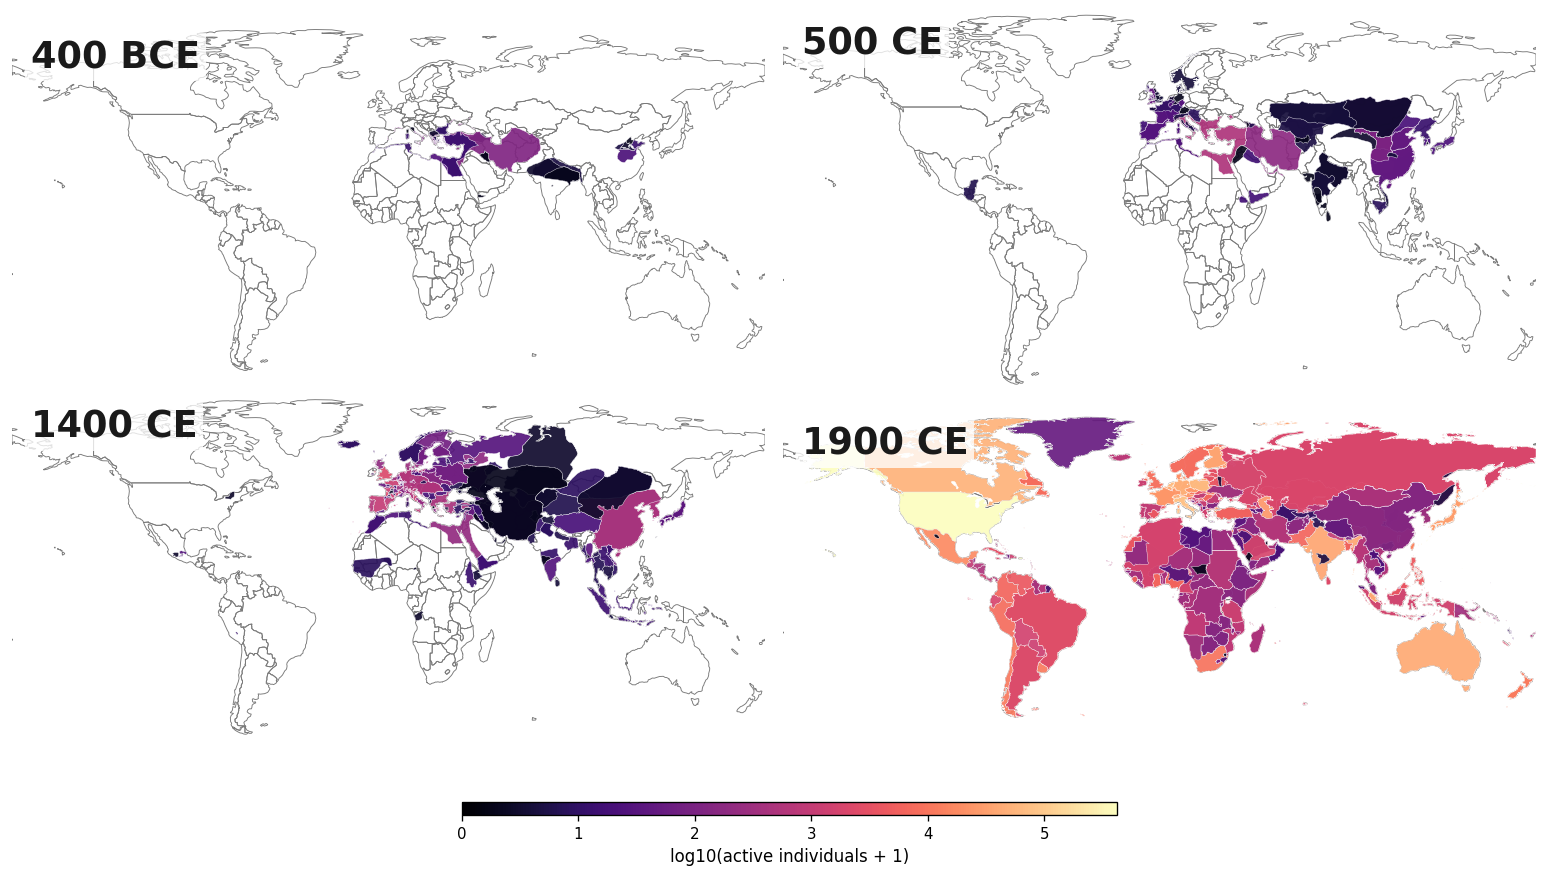

In [17]:
render_century_maps(all_counts_per_century, 'log10(active individuals + 1)')

### Scientists

/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_13681/1315537694.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.97])


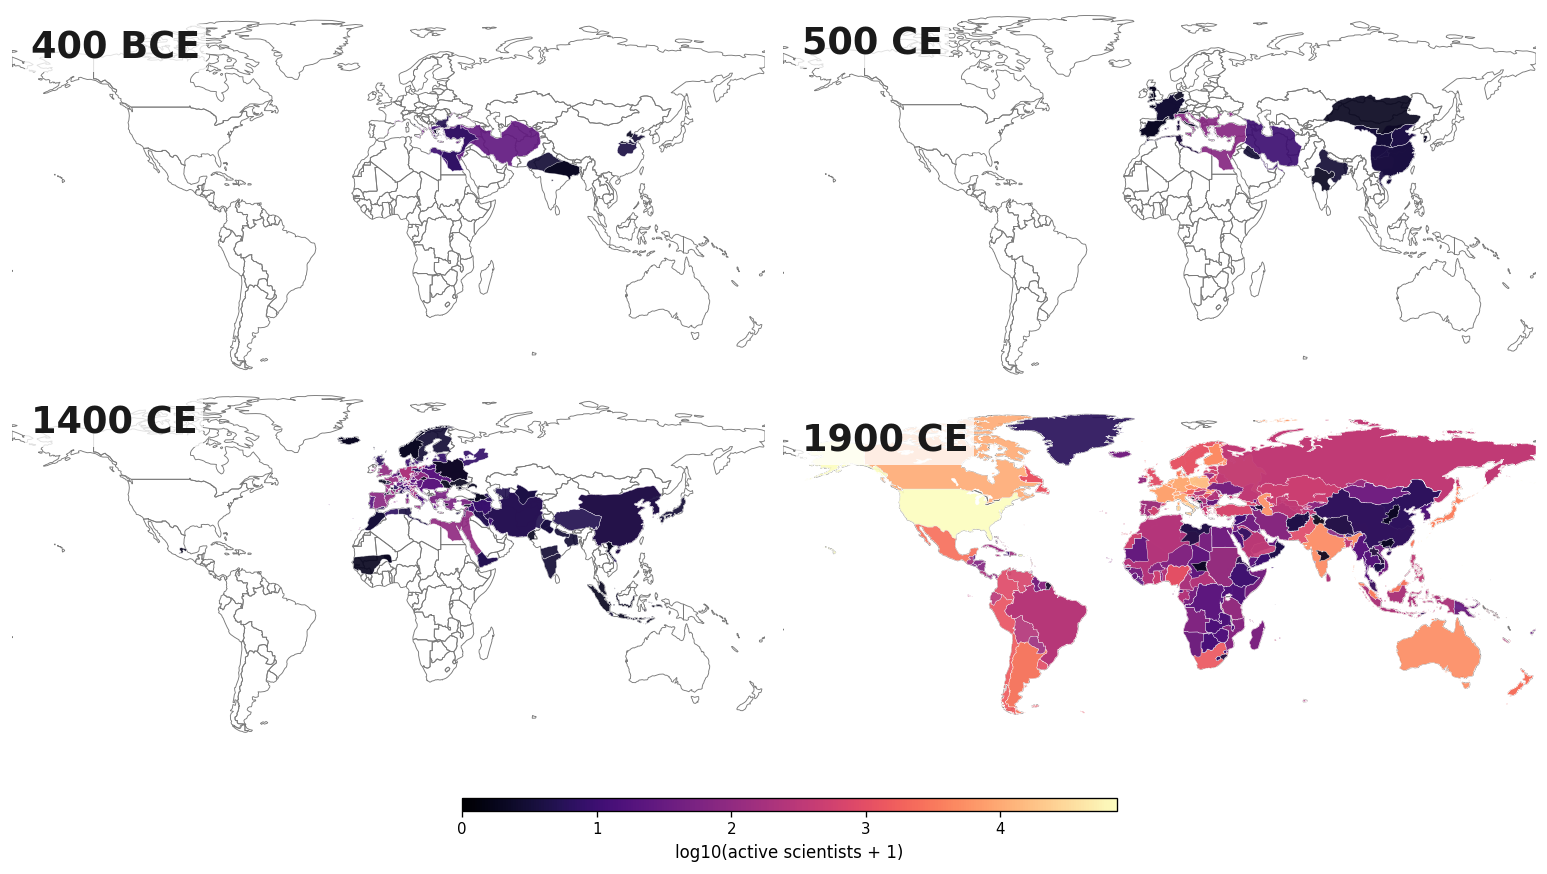

In [18]:
render_century_maps(scientist_counts_per_century, 'log10(active scientists + 1)')